<a href="https://colab.research.google.com/github/beyzanurkeles/Medical-Imaging-Tumor-Segmentation-UNet./blob/main/UNet%2B%2B_(Partial)(400).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Doğru olan bu

Google Drive Bağlama

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Klasörler + Pair Kontrol
import os

base_path = "/content/drive/MyDrive/dataset/"

train_img_dir = os.path.join(base_path, "train/images/")
train_msk_dir = os.path.join(base_path, "train/masks/")
test_img_dir  = os.path.join(base_path, "test/images/")
test_msk_dir  = os.path.join(base_path, "test/masks/")

print("Train images:", train_img_dir)
print("Train masks :", train_msk_dir)
print("Test images :", test_img_dir)
print("Test masks  :", test_msk_dir)

def get_pairs_nifti(img_dir, msk_dir):
    img_files = sorted([f for f in os.listdir(img_dir) if f.endswith("_0000.nii.gz")])
    pairs = []
    for f in img_files:
        pid = f.replace("_0000.nii.gz", "")
        m = pid + ".nii.gz"
        if os.path.exists(os.path.join(msk_dir, m)):
            pairs.append((f, m))
    return pairs

train_pairs = get_pairs_nifti(train_img_dir, train_msk_dir)
test_pairs  = get_pairs_nifti(test_img_dir, test_msk_dir)

print("Train samples:", len(train_pairs))
print("Test samples :", len(test_pairs))


Train images: /content/drive/MyDrive/dataset/train/images/
Train masks : /content/drive/MyDrive/dataset/train/masks/
Test images : /content/drive/MyDrive/dataset/test/images/
Test masks  : /content/drive/MyDrive/dataset/test/masks/
Train samples: 480
Test samples : 120


In [ ]:
# Sanity Check (kısa – örnek bazı case’ler)
import nibabel as nib
import numpy as np

TARGET_SHAPE = (160,160,80)

def quick_check(img_path, msk_path):
    img_nii = nib.load(img_path)
    msk_nii = nib.load(msk_path)
    img = np.asanyarray(img_nii.dataobj)
    msk = np.asanyarray(msk_nii.dataobj)

    print("shape img/msk:", img.shape, msk.shape)
    print("dtype img/msk:", img.dtype, msk.dtype)
    print("mean/std:", float(img.mean()), float(img.std()))
    print("mask unique:", np.unique(msk))

# 3 tane örnek kontrol
for f, m in train_pairs[:3]:
    print("\n---", f, "---")
    quick_check(os.path.join(train_img_dir, f), os.path.join(train_msk_dir, m))



--- ispy1_1001_0000.nii.gz ---
shape img/msk: (160, 160, 80) (160, 160, 80)
dtype img/msk: float32 uint8
mean/std: -4.76837147544984e-09 1.0
mask unique: [0 1]

--- ispy1_1002_0000.nii.gz ---
shape img/msk: (160, 160, 80) (160, 160, 80)
dtype img/msk: float32 uint8
mean/std: 7.510185362491484e-09 1.0000001192092896
mask unique: [0 1]

--- ispy1_1003_0000.nii.gz ---
shape img/msk: (160, 160, 80) (160, 160, 80)
dtype img/msk: float32 uint8
mean/std: -2.396106779656293e-08 1.0000001192092896
mask unique: [0 1]


In [ ]:
# NIfTI Loader (TF Dataset için doğru)
import tensorflow as tf

def load_nifti_numpy(img_path, msk_path):
    img_path = img_path.decode()
    msk_path = msk_path.decode()

    img_nii = nib.load(img_path)
    msk_nii = nib.load(msk_path)

    # Diskten gerçek data
    img = np.asanyarray(img_nii.dataobj).astype(np.float32)
    msk = np.asanyarray(msk_nii.dataobj).astype(np.uint8)

    if img.shape != TARGET_SHAPE:
        raise ValueError(f"IMG shape {img.shape} != {TARGET_SHAPE}")
    if msk.shape != TARGET_SHAPE:
        raise ValueError(f"MSK shape {msk.shape} != {TARGET_SHAPE}")

    # Binary mask
    msk = (msk > 0).astype(np.uint8)

    # Channel ekle (D,H,W,1)
    img = np.expand_dims(img, axis=-1)
    msk = np.expand_dims(msk, axis=-1)

    return img, msk

def load_nifti_tf(img_file, msk_file, img_dir, msk_dir):
    img_path = tf.strings.join([img_dir, img_file])
    msk_path = tf.strings.join([msk_dir, msk_file])

    img, msk = tf.numpy_function(
        load_nifti_numpy,
        [img_path, msk_path],
        [tf.float32, tf.uint8]
    )
    img.set_shape([*TARGET_SHAPE, 1])
    msk.set_shape([*TARGET_SHAPE, 1])
    return img, msk


In [ ]:
# Augmentation (flip + noise + gamma)
def augment_3d(img, msk):
    # Flip X/Y/Z
    if tf.random.uniform(()) > 0.5:
        img = tf.reverse(img, axis=[0]); msk = tf.reverse(msk, axis=[0])
    if tf.random.uniform(()) > 0.5:
        img = tf.reverse(img, axis=[1]); msk = tf.reverse(msk, axis=[1])
    if tf.random.uniform(()) > 0.5:
        img = tf.reverse(img, axis=[2]); msk = tf.reverse(msk, axis=[2])

    # Noise (image only)
    img = img + tf.random.normal(tf.shape(img), stddev=0.02)

    # # Gamma (image only)
    # gamma = tf.random.uniform([], 0.9, 1.1)
    # img = tf.pow(tf.maximum(img, -5.0), gamma)  # güvenli clip benzeri (çok agresif değil)

    return img, msk


In [ ]:
# tf.data Dataset
def create_dataset(pairs, img_dir, msk_dir, batch_size=2, augment=False, shuffle=True):
    img_files = tf.constant([p[0] for p in pairs])
    msk_files = tf.constant([p[1] for p in pairs])

    ds = tf.data.Dataset.from_tensor_slices((img_files, msk_files))
    if shuffle:
        ds = ds.shuffle(len(pairs), reshuffle_each_iteration=True)

    ds = ds.map(lambda i, m: load_nifti_tf(i, m, img_dir, msk_dir),
                num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.map(augment_3d, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


In [ ]:
# Train/Val Split
from sklearn.model_selection import train_test_split

train_pairs_split, val_pairs = train_test_split(
    train_pairs, test_size=0.2, random_state=42
)

train_ds = create_dataset(train_pairs_split, train_img_dir, train_msk_dir, batch_size=2, augment=True, shuffle=True)
val_ds   = create_dataset(val_pairs,       train_img_dir, train_msk_dir, batch_size=2, augment=False, shuffle=False)
test_ds  = create_dataset(test_pairs,      test_img_dir,  test_msk_dir,  batch_size=1, augment=False, shuffle=False)

print("✅ Train/Val/Test hazır")


✅ Train/Val/Test hazır


In [ ]:
# Model (logits çıkışlı)
from tensorflow.keras import layers, models

def conv_block(x, f):
    x = layers.Conv3D(f, 3, padding="same", activation="relu")(x)
    x = layers.Conv3D(f, 3, padding="same", activation="relu")(x)
    return x

def build_unetpp_like_3d(input_shape=(160,160,80,1), base_filters=16):
    inp = layers.Input(input_shape)

    c0 = conv_block(inp, base_filters)
    p0 = layers.MaxPool3D()(c0)

    c1 = conv_block(p0, base_filters*2)
    p1 = layers.MaxPool3D()(c1)

    c2 = conv_block(p1, base_filters*4)
    p2 = layers.MaxPool3D()(c2)

    c3 = conv_block(p2, base_filters*8)

    u2 = layers.UpSampling3D()(c3)
    c2_1 = conv_block(layers.Concatenate()([c2, u2]), base_filters*4)

    u1 = layers.UpSampling3D()(c2_1)
    c1_1 = conv_block(layers.Concatenate()([c1, u1]), base_filters*2)

    u0 = layers.UpSampling3D()(c1_1)
    c0_1 = conv_block(layers.Concatenate()([c0, u0]), base_filters)

    # 🔥 LOGITS (sigmoid YOK)
    out_logits = layers.Conv3D(1, 1, activation=None, name="logits")(c0_1)
    return models.Model(inp, out_logits)

model = build_unetpp_like_3d()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 80, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 160, 160,  │        448 │ input_layer[0][0] │
│                     │ 80, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 160, 160,  │      6,928 │ conv3d[0][0]      │
│                     │ 80, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 80, 80,    │          0 │ conv3d_1[0][0]    │
│ (MaxPooling3D)      │ 40, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 80, 80,    │     13,856 │ max_pooling3d[0]… │
│                     │ 40, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 80, 80,    │     27,680 │ conv3d_2[0][0]    │
│                     │ 40, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 40, 40,    │          0 │ conv3d_3[0][0]    │
│ (MaxPooling3D)      │ 20, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 40, 40,    │     55,360 │ max_pooling3d_1[… │
│                     │ 20, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_5 (Conv3D)   │ (None, 40, 40,    │    110,656 │ conv3d_4[0][0]    │
│                     │ 20, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_2     │ (None, 20, 20,    │          0 │ conv3d_5[0][0]    │
│ (MaxPooling3D)      │ 10, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_6 (Conv3D)   │ (None, 20, 20,    │    221,312 │ max_pooling3d_2[… │
│                     │ 10, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_7 (Conv3D)   │ (None, 20, 20,    │    442,496 │ conv3d_6[0][0]    │
│                     │ 10, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling3d       │ (None, 40, 40,    │          0 │ conv3d_7[0][0]    │
│ (UpSampling3D)      │ 20, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40, 40,    │          0 │ conv3d_5[0][0],   │
│ (Concatenate)       │ 20, 192)          │            │ up_sampling3d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_8 (Conv3D)   │ (None, 40, 40,    │    331,840 │ concatenate[0][0] │
│                     │ 20, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_9 (Conv3D)   │ (None, 40, 40,    │    110,656 │ conv3d_8[0][0]    │
│                     │ 20, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling3d_1     │ (None, 80, 80,    │          0 │ conv3d_9[0][0]  

 Total params: 1,459,585 (5.57 MB)

 Trainable params: 1,459,585 (5.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Loss + Metric (doğru)
def dice_loss_from_logits(y_true, logits):
    y_true = tf.cast(y_true, tf.float32)
    probs = tf.sigmoid(logits)

    inter = tf.reduce_sum(y_true * probs)
    denom = tf.reduce_sum(y_true) + tf.reduce_sum(probs)

    eps = 1e-6
    dice = (2.0 * inter + eps) / (denom + eps)

    return 1.0 - dice


def bce_dice_loss(y_true, logits):
    y_true = tf.cast(y_true, tf.float32)

    bce = tf.nn.sigmoid_cross_entropy_with_logits(labels=y_true, logits=logits)
    bce = tf.reduce_mean(bce)

    dice = dice_loss_from_logits(y_true, logits)
    return 0.5*bce + 0.5*dice

def soft_dice_metric(y_true, logits):
    y_true = tf.cast(y_true, tf.float32)
    probs = tf.sigmoid(logits)

    inter = tf.reduce_sum(y_true * probs)
    denom = tf.reduce_sum(y_true) + tf.reduce_sum(probs) + 1e-7
    return (2.0 * inter + 1e-7) / denom

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=bce_dice_loss,
    metrics=[soft_dice_metric]
)


In [ ]:
# Callbacks + Train
import os
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping

exp_dir = "/content/drive/MyDrive/UNet_experiments/UNetpp_3D_NIFTI_run_fixed"
os.makedirs(exp_dir, exist_ok=True)

best_model_path = os.path.join(exp_dir, "unetpp_best.keras")
last_model_path = os.path.join(exp_dir, "unetpp_last.keras")

callbacks = [
    ModelCheckpoint(best_model_path, monitor="val_loss", save_best_only=True, mode="min", verbose=1),
    ModelCheckpoint(last_model_path, save_best_only=False, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1),
    # EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1),
    CSVLogger(os.path.join(exp_dir, "training_log.csv"))
]




Eğitim

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=150,     # 300 yerine önce 200 öneririm (gerekirse uzatırız)
    callbacks=callbacks
)

Epoch 1/150
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.6119 - soft_dice_metric: 0.0118
Epoch 1: val_loss improved from inf to 0.46953, saving model to /content/drive/MyDrive/UNet_experiments/UNetpp_3D_NIFTI_run_fixed/unetpp_best.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - loss: 0.6113 - soft_dice_metric: 0.0120 - val_loss: 0.4695 - val_soft_dice_metric: 0.1025 - learning_rate: 1.0000e-04
Epoch 2/150
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.4535 - soft_dice_metric: 0.1358
Epoch 2: val_loss improved from 0.46953 to 0.39460, saving model to /content/drive/MyDrive/UNet_experiments/UNetpp_3D_NIFTI_run_fixed/unetpp_best.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - loss: 0.4534 - soft_dice_metric: 0.1360 - val_loss: 0.3946 - val_soft_dice_metric: 0.2460 - learning_rate: 1.0000e-04
Epoch 3/150
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.3423 - soft_dice_metric: 0.3447
Epoch 3: val_loss improved from 0.39460 to 0.31793, saving model to /content/drive/MyDrive/UNe

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
best_model_path = "/content/drive/MyDrive/UNet_experiments/UNetpp_3D_NIFTI_run_fixed/unetpp_best.keras"

model = tf.keras.models.load_model(
    best_model_path,
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "soft_dice_metric": soft_dice_metric,
        "dice_loss_from_logits": dice_loss_from_logits
    }
)


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=300,
    initial_epoch=150,
    callbacks=callbacks
)


Epoch 151/300
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.1616 - soft_dice_metric: 0.6926
Epoch 151: val_loss improved from inf to 0.22339, saving model to /content/drive/MyDrive/UNet_experiments/UNetpp_3D_NIFTI_run_fixed/unetpp_best.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - loss: 0.1616 - soft_dice_metric: 0.6925 - val_loss: 0.2234 - val_soft_dice_metric: 0.5866 - learning_rate: 5.0000e-05
Epoch 152/300
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.1709 - soft_dice_metric: 0.6737
Epoch 152: val_loss improved from 0.22339 to 0.21758, saving model to /content/drive/MyDrive/UNet_experiments/UNetpp_3D_NIFTI_run_fixed/unetpp_best.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - loss: 0.1708 - soft_dice_metric: 0.6738 - val_loss: 0.2176 - val_soft_dice_metric: 0.5944 - learning_rate: 5.0000e-05
Epoch 153/300
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.1642 - soft_dice_metric: 0.6877
Epoch 153: val_loss improved from 0.21758 to 0.21289, saving model to /content/drive

In [ ]:
best_model_path = "/content/drive/MyDrive/UNet_experiments/UNetpp_3D_NIFTI_run_fixed/unetpp_best.keras"

model = tf.keras.models.load_model(
    best_model_path,
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "soft_dice_metric": soft_dice_metric,
        "dice_loss_from_logits": dice_loss_from_logits
    }
)


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=300,
    initial_epoch=201,
    callbacks=callbacks
)


Epoch 202/300
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.1415 - soft_dice_metric: 0.7305
Epoch 202: val_loss did not improve from 0.20620
128/128 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - loss: 0.1414 - soft_dice_metric: 0.7306 - val_loss: 0.2125 - val_soft_dice_metric: 0.6045 - learning_rate: 2.5000e-05
Epoch 203/300
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.1387 - soft_dice_metric: 0.7361
Epoch 203: val_loss did not improve from 0.20620
128/128 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - loss: 0.1387 - soft_dice_metric: 0.7362 - val_loss: 0.2101 - val_soft_dice_metric: 0.6110 - learning_rate: 2.5000e-05
Epoch 204/300
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.1295 - soft_dice_metric: 0.7521
Epoch 204: val_loss did not improve from 0.20620
128/128 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - loss: 0.1295 - soft_dice_metric: 0.7521 - val_loss: 0.2150 - val_soft_dice_metric: 0.6017 - learning_rate: 2.5000e-05
Epoch 205/300
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.1263 - soft_dic

KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os


In [ ]:
BEST_PATH = "/content/drive/MyDrive/UNet_experiments/UNetpp_3D_NIFTI_run_fixed/unetpp_best.keras"

best_model = tf.keras.models.load_model(
    BEST_PATH,
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "soft_dice_metric": soft_dice_metric,
        "dice_loss_from_logits": dice_loss_from_logits
    },
    compile=False
)

print("✅ Best model yüklendi")


✅ Best model yüklendi


In [ ]:
BEST_PATH = "/content/drive/MyDrive/unetpp_best.keras"

best_model = tf.keras.models.load_model(
    BEST_PATH,
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "soft_dice_metric": soft_dice_metric,
        "dice_loss_from_logits": dice_loss_from_logits
    },
    compile=False
)

print("✅ Best model yüklendi")


✅ Best model yüklendi


In [ ]:
def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))
def compute_case_metrics(y_true, y_prob, thr=0.5):
    y_true = (y_true > 0.5).astype(np.uint8).ravel()
    y_pred = (y_prob > thr).astype(np.uint8).ravel()

    tp = np.logical_and(y_true==1, y_pred==1).sum()
    tn = np.logical_and(y_true==0, y_pred==0).sum()
    fp = np.logical_and(y_true==0, y_pred==1).sum()
    fn = np.logical_and(y_true==1, y_pred==0).sum()

    dice = (2*tp + 1e-7) / (2*tp + fp + fn + 1e-7)
    iou  = (tp + 1e-7) / (tp + fp + fn + 1e-7)
    prec = (tp + 1e-7) / (tp + fp + 1e-7)
    rec  = (tp + 1e-7) / (tp + fn + 1e-7)

    return {
        "Dice": dice,
        "FN": fn,
        "FP": fp,
        "IoU": iou,
        "TN": tn,
        "TP": tp,
        "n_pred": y_pred.sum(),
        "n_ref": y_true.sum(),
        "Precision": prec,
        "Recall": rec
    }
def evaluate_dataset(model, dataset, thr=0.5):
    rows = []

    for x, y in dataset:
        logits = model.predict(x, verbose=0)
        probs  = sigmoid_np(logits)
        y_true = y.numpy()

        rows.append(
            compute_case_metrics(y_true, probs, thr)
        )

    df_cases = pd.DataFrame(rows)
    df_mean  = df_cases.mean(numeric_only=True).to_frame().T

    return df_cases, df_mean

THR = 0.4

val_ds_eval = create_dataset(
    val_pairs,
    train_img_dir,
    train_msk_dir,
    batch_size=1,
    augment=False,
    shuffle=False
)

df_val_cases, df_val_mean = evaluate_dataset(
    best_model,
    val_ds_eval,
    thr=THR
)

print("===== VALIDATION MEAN =====")
display(df_val_mean[["Dice","FN","FP","IoU","TN","TP","n_pred","n_ref"]])

OUT_DIR = "/content/drive/MyDrive/UNet_experiments/UNetpp_3D_NIFTI_run_fixed/metrics"
os.makedirs(OUT_DIR, exist_ok=True)

df_val_mean.to_csv(os.path.join(OUT_DIR, "VAL_mean_thr0.5.csv"), index=False)
df_val_cases.to_csv(os.path.join(OUT_DIR, "VAL_cases_thr0.5.csv"), index=False)

print("✅ Validation metrikleri kaydedildi")



/tmp/ipython-input-1532732387.py:2: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


===== VALIDATION MEAN =====


,Dice,FN,FP,IoU,TN,TP,n_pred,n_ref
0,0.634457,2113.0,2120.84375,0.512256,2.039034e+06,4731.947917,6852.791667,6844.947917


✅ Validation metrikleri kaydedildi


In [ ]:
def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))
def compute_case_metrics(y_true, y_prob, thr=0.5):
    y_true = (y_true > 0.5).astype(np.uint8).ravel()
    y_pred = (y_prob > thr).astype(np.uint8).ravel()

    tp = np.logical_and(y_true==1, y_pred==1).sum()
    tn = np.logical_and(y_true==0, y_pred==0).sum()
    fp = np.logical_and(y_true==0, y_pred==1).sum()
    fn = np.logical_and(y_true==1, y_pred==0).sum()

    dice = (2*tp + 1e-7) / (2*tp + fp + fn + 1e-7)
    iou  = (tp + 1e-7) / (tp + fp + fn + 1e-7)
    prec = (tp + 1e-7) / (tp + fp + 1e-7)
    rec  = (tp + 1e-7) / (tp + fn + 1e-7)

    return {
        "Dice": dice,
        "FN": fn,
        "FP": fp,
        "IoU": iou,
        "TN": tn,
        "TP": tp,
        "n_pred": y_pred.sum(),
        "n_ref": y_true.sum(),
        "Precision": prec,
        "Recall": rec
    }
def evaluate_dataset(model, dataset, thr=0.5):
    rows = []

    for x, y in dataset:
        logits = model.predict(x, verbose=0)
        probs  = sigmoid_np(logits)
        y_true = y.numpy()

        rows.append(
            compute_case_metrics(y_true, probs, thr)
        )

    df_cases = pd.DataFrame(rows)
    df_mean  = df_cases.mean(numeric_only=True).to_frame().T

    return df_cases, df_mean

THR = 0.4

val_ds_eval = create_dataset(
    val_pairs,
    train_img_dir,
    train_msk_dir,
    batch_size=1,
    augment=False,
    shuffle=False
)

df_val_cases, df_val_mean = evaluate_dataset(
    best_model,
    val_ds_eval,
    thr=THR
)

print("===== VALIDATION MEAN =====")
display(df_val_mean[["Dice","FN","FP","IoU","TN","TP","n_pred","n_ref"]])

OUT_DIR = "/content/drive/MyDrive/UNet_experiments/UNetpp_3D_NIFTI_run_fixed/metrics1"
os.makedirs(OUT_DIR, exist_ok=True)

df_val_mean.to_csv(os.path.join(OUT_DIR, "VAL_mean_thr0.5.csv"), index=False)
df_val_cases.to_csv(os.path.join(OUT_DIR, "VAL_cases_thr0.5.csv"), index=False)

print("✅ Validation metrikleri kaydedildi")



/tmp/ipython-input-4112173830.py:2: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


===== VALIDATION MEAN =====


,Dice,FN,FP,IoU,TN,TP,n_pred,n_ref
0,0.634457,2113.0,2120.84375,0.512256,2.039034e+06,4731.947917,6852.791667,6844.947917


✅ Validation metrikleri kaydedildi


TRAIN METRİKLERİ

In [ ]:
train_ds_eval = create_dataset(
    train_pairs,
    train_img_dir,
    train_msk_dir,
    batch_size=1,
    augment=False,
    shuffle=False
)


In [ ]:
df_train_cases, df_train_mean = evaluate_dataset(
    best_model,
    train_ds_eval,
    thr=0.5
)


/tmp/ipython-input-4112173830.py:2: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


In [ ]:
# print("===== TRAIN MEAN =====")
# display(
#     df_train_mean[
#         ["Dice", "FN", "FP", "IoU", "TN", "TP", "n_pred", "n_ref", "Precision", "Recall"]
#     ]
# )

# df_train_mean.to_csv(
#     os.path.join(OUT_DIR, "TRAIN_mean_thr0.5.csv"),
#     index=False
# )

# df_train_cases.to_csv(
#     os.path.join(OUT_DIR, "TRAIN_cases_thr0.5.csv"),
#     index=False
# )

# print("✅ Train metrikleri kaydedildi")


===== TRAIN MEAN =====


,Dice,FN,FP,IoU,TN,TP,n_pred,n_ref,Precision,Recall
0,0.712512,2671.265625,1777.9375,0.592592,2.036852e+06,6698.325,8476.2625,9369.590625,0.757393,0.749192


✅ Train metrikleri kaydedildi


TEST METRİKLERİ

In [ ]:
test_ds_eval = create_dataset(
    test_pairs,
    test_img_dir,
    test_msk_dir,
    batch_size=1,
    augment=False,
    shuffle=False
)


In [ ]:
df_test_cases, df_test_mean = evaluate_dataset(
    best_model,
    test_ds_eval,
    thr=THR
)

print("===== TEST MEAN =====")
display(df_test_mean[["Dice","Precision","Recall","IoU"]])


/tmp/ipython-input-4112173830.py:2: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


===== TEST MEAN =====


,Dice,Precision,Recall,IoU
0,0.630503,0.695031,0.67344,0.505838


In [ ]:
df_test_mean.to_csv(os.path.join(OUT_DIR, "TEST_mean_thr0.5.csv"), index=False)
df_test_cases.to_csv(os.path.join(OUT_DIR, "TEST_cases_thr0.5.csv"), index=False)

print("✅ Test metrikleri kaydedildi")


✅ Test metrikleri kaydedildi


In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.ndimage import binary_erosion, distance_transform_edt

# 1. Önce Test Dataset'ini Hazırla (Eğer daha önce tanımlamadıysan)
# Not: val_ds_eval'i nasıl oluşturduysan aynı şekilde test verilerin için oluşturmalısın.
# test_ds_eval = ...

def hd95_binary(y_true, y_pred):
    """
    y_true, y_pred : (D,H,W) binary (0/1)
    return          : HD95 (voxel)
    """
    y_true = (y_true > 0).astype(np.uint8)
    y_pred = (y_pred > 0).astype(np.uint8)

    if y_true.sum() == 0 and y_pred.sum() == 0:
        return 0.0
    if y_true.sum() == 0 or y_pred.sum() == 0:
        return np.nan

    true_surf = y_true ^ binary_erosion(y_true)
    pred_surf = y_pred ^ binary_erosion(y_pred)

    dt_true = distance_transform_edt(1 - true_surf)
    dt_pred = distance_transform_edt(1 - pred_surf)

    d1 = dt_true[pred_surf.astype(bool)]
    d2 = dt_pred[true_surf.astype(bool)]

    if len(d1) == 0 or len(d2) == 0:
        return np.nan

    all_d = np.concatenate([d1, d2], axis=0)
    return float(np.percentile(all_d, 95))

def evaluate_hd95(model, dataset, thr=0.5, max_cases=None):
    hd_list = []

    for i, (x, y) in enumerate(dataset, 1):
        # Keras predict kullanımı
        logits = model.predict(x, verbose=0)
        probs  = 1.0 / (1.0 + np.exp(-logits))   # sigmoid
        pred   = (probs > thr).astype(np.uint8)

        # Dataset yapına göre y'yi numpy'a çevir
        y_true = y.numpy() if hasattr(y, "numpy") else np.array(y)
        y_true = y_true.astype(np.uint8)

        # Boyutları (D, H, W) formatına getir
        # Senin yapında (1, D, H, W, 1) olduğu için:
        hd = hd95_binary(
            y_true[0, ..., 0],
            pred[0, ..., 0]
        )

        hd_list.append(hd)
        if max_cases is not None and i >= max_cases:
            break

    hd_arr = np.array(hd_list, dtype=np.float32)
    return float(np.nanmean(hd_arr)), hd_list

# --- TEST HESAPLAMA ---
print("🚀 TEST HD95 hesaplanıyor...")
test_hd95_mean, test_hd95_cases = evaluate_hd95(
    best_model,
    test_ds_eval,  # <-- Validation değil Test datasetini veriyoruz
    thr=0.5
)

print(f"✅ TEST HD95 (mean): {test_hd95_mean:.4f}")

# --- KAYDETME İŞLEMLERİ ---
OUT_DIR = "/content/drive/MyDrive/nnUNet_results/outputs/" # Kendi klasör yolunu yaz
os.makedirs(OUT_DIR, exist_ok=True)

np.savetxt(
    os.path.join(OUT_DIR, "TEST_hd95_cases.txt"),
    np.array(test_hd95_cases),
    fmt="%.4f"
)

# Tabloya (DataFrame) eklemek istersen
df_test_results = pd.DataFrame({
    "Case": range(len(test_hd95_cases)),
    "HD95": test_hd95_cases
})
df_test_results.to_csv(os.path.join(OUT_DIR, "TEST_metrics_final.csv"), index=False)

print("✅ Tüm test sonuçları kaydedildi.")

🚀 TEST HD95 hesaplanıyor...


/tmp/ipython-input-4137111045.py:44: RuntimeWarning: overflow encountered in exp
  probs  = 1.0 / (1.0 + np.exp(-logits))   # sigmoid


✅ TEST HD95 (mean): 17.5424
✅ Tüm test sonuçları kaydedildi.


HD95 HESAPLAMA (TRAIN / VAL / TEST)

In [ ]:
import numpy as np
from scipy.ndimage import binary_erosion, distance_transform_edt


In [ ]:
df_test_mean.to_csv(os.path.join(OUT_DIR, "TEST_mean_thr0.5.csv"), index=False)
df_test_cases.to_csv(os.path.join(OUT_DIR, "TEST_cases_thr0.5.csv"), index=False)

print("✅ Test metrikleri kaydedildi")


NameError: name 'df_test_mean' is not defined

In [ ]:
def hd95_binary(y_true, y_pred):
    """
    y_true, y_pred : (D,H,W) binary (0/1)
    return          : HD95 (voxel)
    """

    y_true = (y_true > 0).astype(np.uint8)
    y_pred = (y_pred > 0).astype(np.uint8)

    # İkisi de boşsa → 0 kabul edelim
    if y_true.sum() == 0 and y_pred.sum() == 0:
        return 0.0

    # Biri boşsa → ölçülemez (nan)
    if y_true.sum() == 0 or y_pred.sum() == 0:
        return np.nan

    # Surface (kenar) çıkar
    true_surf = y_true ^ binary_erosion(y_true)
    pred_surf = y_pred ^ binary_erosion(y_pred)

    # Distance transform
    dt_true = distance_transform_edt(1 - true_surf)
    dt_pred = distance_transform_edt(1 - pred_surf)

    # Karşılıklı yüzey mesafeleri
    d1 = dt_true[pred_surf.astype(bool)]
    d2 = dt_pred[true_surf.astype(bool)]

    all_d = np.concatenate([d1, d2], axis=0)

    return float(np.percentile(all_d, 95))


In [ ]:
def evaluate_hd95(model, dataset, thr=0.5, max_cases=None):
    hd_list = []

    for i, (x, y) in enumerate(dataset, 1):
        logits = model.predict(x, verbose=0)
        probs  = 1.0 / (1.0 + np.exp(-logits))   # sigmoid
        pred   = (probs > thr).astype(np.uint8)

        y_true = y.numpy().astype(np.uint8)

        # (1,D,H,W,1) -> (D,H,W)
        hd = hd95_binary(
            y_true[0, ..., 0],
            pred[0, ..., 0]
        )

        hd_list.append(hd)

        if max_cases is not None and i >= max_cases:
            break

    hd_arr = np.array(hd_list, dtype=np.float32)
    return float(np.nanmean(hd_arr)), hd_list


In [ ]:
val_hd95_mean, val_hd95_cases = evaluate_hd95(
    best_model,
    val_ds_eval,
    thr=0.5
)

print("✅ VAL HD95 (mean):", val_hd95_mean)


/tmp/ipython-input-1613407315.py:6: RuntimeWarning: overflow encountered in exp
  probs  = 1.0 / (1.0 + np.exp(-logits))   # sigmoid


✅ VAL HD95 (mean): 15.142112731933594


In [ ]:
val_hd95_mean, val_hd95_cases = evaluate_hd95(
    best_model,
    val_ds_eval,
    thr=0.5
)

print("✅ VAL HD95 (mean):", val_hd95_mean)


/tmp/ipython-input-1613407315.py:6: RuntimeWarning: overflow encountered in exp
  probs  = 1.0 / (1.0 + np.exp(-logits))   # sigmoid


✅ VAL HD95 (mean): 15.607610702514648


In [ ]:
# np.savetxt(
#     os.path.join(OUT_DIR, "TRAIN_hd95_cases.txt"),
#     np.array(train_hd95_cases),
#     fmt="%.4f"
# )

np.savetxt(
    os.path.join(OUT_DIR, "VAL_hd95_cases.txt"),
    np.array(val_hd95_cases),
    fmt="%.4f"
)

np.savetxt(
    os.path.join(OUT_DIR, "TEST_hd95_cases.txt"),
    np.array(test_hd95_cases),
    fmt="%.4f"
)

print("✅ HD95 case-wise değerler kaydedildi")


NameError: name 'test_hd95_cases' is not defined

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.ndimage import binary_erosion, distance_transform_edt

# 1. Önce Test Dataset'ini Hazırla (Eğer daha önce tanımlamadıysan)
# Not: val_ds_eval'i nasıl oluşturduysan aynı şekilde test verilerin için oluşturmalısın.
# test_ds_eval = ...

def hd95_binary(y_true, y_pred):
    """
    y_true, y_pred : (D,H,W) binary (0/1)
    return          : HD95 (voxel)
    """
    y_true = (y_true > 0).astype(np.uint8)
    y_pred = (y_pred > 0).astype(np.uint8)

    if y_true.sum() == 0 and y_pred.sum() == 0:
        return 0.0
    if y_true.sum() == 0 or y_pred.sum() == 0:
        return np.nan

    true_surf = y_true ^ binary_erosion(y_true)
    pred_surf = y_pred ^ binary_erosion(y_pred)

    dt_true = distance_transform_edt(1 - true_surf)
    dt_pred = distance_transform_edt(1 - pred_surf)

    d1 = dt_true[pred_surf.astype(bool)]
    d2 = dt_pred[true_surf.astype(bool)]

    if len(d1) == 0 or len(d2) == 0:
        return np.nan

    all_d = np.concatenate([d1, d2], axis=0)
    return float(np.percentile(all_d, 95))

def evaluate_hd95(model, dataset, thr=0.5, max_cases=None):
    hd_list = []

    for i, (x, y) in enumerate(dataset, 1):
        # Keras predict kullanımı
        logits = model.predict(x, verbose=0)
        probs  = 1.0 / (1.0 + np.exp(-logits))   # sigmoid
        pred   = (probs > thr).astype(np.uint8)

        # Dataset yapına göre y'yi numpy'a çevir
        y_true = y.numpy() if hasattr(y, "numpy") else np.array(y)
        y_true = y_true.astype(np.uint8)

        # Boyutları (D, H, W) formatına getir
        # Senin yapında (1, D, H, W, 1) olduğu için:
        hd = hd95_binary(
            y_true[0, ..., 0],
            pred[0, ..., 0]
        )

        hd_list.append(hd)
        if max_cases is not None and i >= max_cases:
            break

    hd_arr = np.array(hd_list, dtype=np.float32)
    return float(np.nanmean(hd_arr)), hd_list

# --- TEST HESAPLAMA ---
print("🚀 TEST HD95 hesaplanıyor...")
test_hd95_mean, test_hd95_cases = evaluate_hd95(
    best_model,
    test_ds_eval,  # <-- Validation değil Test datasetini veriyoruz
    thr=0.5
)

print(f"✅ TEST HD95 (mean): {test_hd95_mean:.4f}")

# --- KAYDETME İŞLEMLERİ ---
OUT_DIR = "/content/drive/MyDrive/nnUNet_results/outputs/" # Kendi klasör yolunu yaz
os.makedirs(OUT_DIR, exist_ok=True)

np.savetxt(
    os.path.join(OUT_DIR, "TEST_hd95_cases.txt"),
    np.array(test_hd95_cases),
    fmt="%.4f"
)

# Tabloya (DataFrame) eklemek istersen
df_test_results = pd.DataFrame({
    "Case": range(len(test_hd95_cases)),
    "HD95": test_hd95_cases
})
df_test_results.to_csv(os.path.join(OUT_DIR, "TEST_metrics_final.csv"), index=False)

print("✅ Tüm test sonuçları kaydedildi.")

🚀 TEST HD95 hesaplanıyor...


/tmp/ipython-input-4137111045.py:44: RuntimeWarning: overflow encountered in exp
  probs  = 1.0 / (1.0 + np.exp(-logits))   # sigmoid


✅ TEST HD95 (mean): 18.9051
✅ Tüm test sonuçları kaydedildi.


In [ ]:
!pip install medpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 33.4 MB/s eta 0:00:00
  Created wheel for medpy: filename=MedPy-0.5.2-py3-none-any.whl size=224710 sha256=a134901462cf110508065a0f8b5b25055ae6faed396fbe5d5a5c08de775572e7
  Stored in directory: /root/.cache/pip/wheels/89/5a/f8/b3def53b9c2133d2f8698ea2173bb5df63bd8e761ce8e9aec9
Successfully built medpy


In [ ]:
# Kopya al (güvenlik)
df = df_test_cases.copy()

# Hasta indeksini ekleyelim
df["case_index"] = df.index

# Dice'a göre sırala
df_sorted = df.sort_values(by="Dice", ascending=False)


In [ ]:
best_5 = df_sorted.head(5)

print("===== TEST SETİ – EN İYİ 5 HASTA (Dice) =====")
for _, row in best_5.iterrows():
    idx = int(row["case_index"])
    img_path, msk_path = test_pairs[idx]

    print(f"""
Hasta index : {idx}
Image dosyası : {img_path}
Mask dosyası  : {msk_path}
Dice      : {row['Dice']:.4f}
Precision : {row['Precision']:.4f}
Recall    : {row['Recall']:.4f}
FP / FN   : {row['FP']} / {row['FN']}
-----------------------------------------
""")


===== TEST SETİ – EN İYİ 5 HASTA (Dice) =====

Hasta index : 77
Image dosyası : ispy2_353318_0000.nii.gz
Mask dosyası  : ispy2_353318.nii.gz
Dice      : 0.9268
Precision : 0.9565
Recall    : 0.8988
FP / FN   : 411.0 / 1018.0
-----------------------------------------


Hasta index : 64
Image dosyası : ispy2_237158_0000.nii.gz
Mask dosyası  : ispy2_237158.nii.gz
Dice      : 0.8975
Precision : 0.8474
Recall    : 0.9540
FP / FN   : 2633.0 / 705.0
-----------------------------------------


Hasta index : 24
Image dosyası : ispy1_1164_0000.nii.gz
Mask dosyası  : ispy1_1164.nii.gz
Dice      : 0.8877
Precision : 0.8183
Recall    : 0.9699
FP / FN   : 795.0 / 111.0
-----------------------------------------


Hasta index : 49
Image dosyası : ispy1_1238_0000.nii.gz
Mask dosyası  : ispy1_1238.nii.gz
Dice      : 0.8876
Precision : 0.8762
Recall    : 0.8993
FP / FN   : 1242.0 / 985.0
-----------------------------------------


Hasta index : 55
Image dosyası : ispy2_132463_0000.nii.gz
Mask dosyası  : 

In [ ]:
worst_5 = df_sorted.tail(5)

print("===== TEST SETİ – EN KÖTÜ 5 HASTA (Dice) =====")
for _, row in worst_5.iterrows():
    idx = int(row["case_index"])
    img_path, msk_path = test_pairs[idx]

    print(f"""
Hasta index : {idx}
Image dosyası : {img_path}
Mask dosyası  : {msk_path}
Dice      : {row['Dice']:.4f}
Precision : {row['Precision']:.4f}
Recall    : {row['Recall']:.4f}
FP / FN   : {row['FP']} / {row['FN']}
-----------------------------------------
""")


===== TEST SETİ – EN KÖTÜ 5 HASTA (Dice) =====

Hasta index : 74
Image dosyası : ispy2_318293_0000.nii.gz
Mask dosyası  : ispy2_318293.nii.gz
Dice      : 0.0000
Precision : 0.0000
Recall    : 0.0000
FP / FN   : 186.0 / 641.0
-----------------------------------------


Hasta index : 7
Image dosyası : ispy1_1072_0000.nii.gz
Mask dosyası  : ispy1_1072.nii.gz
Dice      : 0.0000
Precision : 1.0000
Recall    : 0.0000
FP / FN   : 0.0 / 2922.0
-----------------------------------------


Hasta index : 25
Image dosyası : ispy1_1169_0000.nii.gz
Mask dosyası  : ispy1_1169.nii.gz
Dice      : 0.0000
Precision : 1.0000
Recall    : 0.0000
FP / FN   : 0.0 / 4465.0
-----------------------------------------


Hasta index : 14
Image dosyası : ispy1_1101_0000.nii.gz
Mask dosyası  : ispy1_1101.nii.gz
Dice      : 0.0000
Precision : 1.0000
Recall    : 0.0000
FP / FN   : 0.0 / 23302.0
-----------------------------------------


Hasta index : 56
Image dosyası : ispy2_139771_0000.nii.gz
Mask dosyası  : ispy2_139

In [ ]:
zero_dice = df[df["Dice"] < 0.01]

print(f"⚠️ Dice ≈ 0 olan hasta sayısı: {len(zero_dice)}")

for _, row in zero_dice.iterrows():
    idx = int(row["case_index"])
    img_path, msk_path = test_pairs[idx]

    print(f"""
Hasta index : {idx}
Image dosyası : {img_path}
Mask dosyası  : {msk_path}
Dice      : {row['Dice']:.4f}
Recall    : {row['Recall']:.4f}
FN        : {row['FN']}
""")


⚠️ Dice ≈ 0 olan hasta sayısı: 7

Hasta index : 7
Image dosyası : ispy1_1072_0000.nii.gz
Mask dosyası  : ispy1_1072.nii.gz
Dice      : 0.0000
Recall    : 0.0000
FN        : 2922.0


Hasta index : 14
Image dosyası : ispy1_1101_0000.nii.gz
Mask dosyası  : ispy1_1101.nii.gz
Dice      : 0.0000
Recall    : 0.0000
FN        : 23302.0


Hasta index : 25
Image dosyası : ispy1_1169_0000.nii.gz
Mask dosyası  : ispy1_1169.nii.gz
Dice      : 0.0000
Recall    : 0.0000
FN        : 4465.0


Hasta index : 37
Image dosyası : ispy1_1203_0000.nii.gz
Mask dosyası  : ispy1_1203.nii.gz
Dice      : 0.0064
Recall    : 0.0048
FN        : 9676.0


Hasta index : 56
Image dosyası : ispy2_139771_0000.nii.gz
Mask dosyası  : ispy2_139771.nii.gz
Dice      : 0.0000
Recall    : 0.0000
FN        : 25532.0


Hasta index : 65
Image dosyası : ispy2_241705_0000.nii.gz
Mask dosyası  : ispy2_241705.nii.gz
Dice      : 0.0016
Recall    : 0.0008
FN        : 1245.0


Hasta index : 74
Image dosyası : ispy2_318293_0000.nii.gz
Mask 

In [ ]:
# # Evaluation: Threshold Sweep (asıl “thresh” burada!)
# from tensorflow.keras.models import load_model
# import numpy as np
# import tensorflow as tf

# best_model = load_model(best_model_path, compile=False)

# # predict için compile şart değil ama metrik/loss kullanacaksan lazım:
# best_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
#                    loss=bce_dice_loss,
#                    metrics=[soft_dice_metric])

# def dice_np(y_true, y_pred):
#     y_true = y_true.astype(np.float32)
#     y_pred = y_pred.astype(np.float32)
#     inter = (y_true * y_pred).sum()
#     denom = y_true.sum() + y_pred.sum() + 1e-7
#     return (2*inter + 1e-7) / denom

# def eval_threshold_sweep(ds, thresholds):
#     # ds: (img, msk) batch=1 olması iyi olur
#     dices = {t: [] for t in thresholds}

#     for imgs, masks in ds:
#         logits = best_model.predict(imgs, verbose=0)
#         probs = 1.0 / (1.0 + np.exp(-logits))  # sigmoid

#         y_true = masks.numpy()
#         for t in thresholds:
#             y_pred = (probs > t).astype(np.uint8)
#             dices[t].append(dice_np(y_true, y_pred))

#     avg = {t: float(np.mean(dices[t])) for t in thresholds}
#     best_t = max(avg, key=avg.get)
#     return best_t, avg[best_t], avg

# # Val dataset'i batch=1 yap
# val_ds_eval = create_dataset(val_pairs, train_img_dir, train_msk_dir, batch_size=1, augment=False, shuffle=False)

# thresholds = [i/100 for i in range(30, 71, 5)]  # 0.30..0.70
# best_thr, best_dice, all_scores = eval_threshold_sweep(val_ds_eval, thresholds)

# print("✅ Best threshold:", best_thr)
# print("✅ Best val dice :", best_dice)
# print("All:", all_scores)


/tmp/ipython-input-2245221214.py:26: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))  # sigmoid


✅ Best threshold: 0.3
✅ Best val dice : 0.6104369163513184
All: {0.3: 0.6104369163513184, 0.35: 0.6100209951400757, 0.4: 0.6098960638046265, 0.45: 0.6094714403152466, 0.5: 0.6096295118331909, 0.55: 0.6093836426734924, 0.6: 0.609035313129425, 0.65: 0.6088466048240662, 0.7: 0.6083283424377441}


In [ ]:
import numpy as np

test_dice_mean = df_test_cases["Dice"].mean()
test_precision_mean = df_test_cases["Precision"].mean()
test_recall_mean = df_test_cases["Recall"].mean()

print("Test Dice Mean      :", test_dice_mean)
print("Test Precision Mean :", test_precision_mean)
print("Test Recall Mean    :", test_recall_mean)


Test Dice Mean      : 0.5512230802101744
Test Precision Mean : 0.7270321738857397
Test Recall Mean    : 0.5708299725179017


In [ ]:
import pandas as pd

test_df = df_test_cases[["Dice", "Precision", "Recall"]].copy()

# Güvenlik: NaN temizle
valid_test = test_df.dropna().reset_index(drop=True)

print("Toplam test vaka:", len(valid_test))


Toplam test vaka: 80


In [ ]:
import os

test_outdir = os.path.join(exp_dir, "test_figs")
os.makedirs(test_outdir, exist_ok=True)

print("Grafikler buraya kaydedilecek:", test_outdir)


Grafikler buraya kaydedilecek: /content/drive/MyDrive/UNet_experiments/UNetpp_3D_NIFTI_run_fixed/test_figs


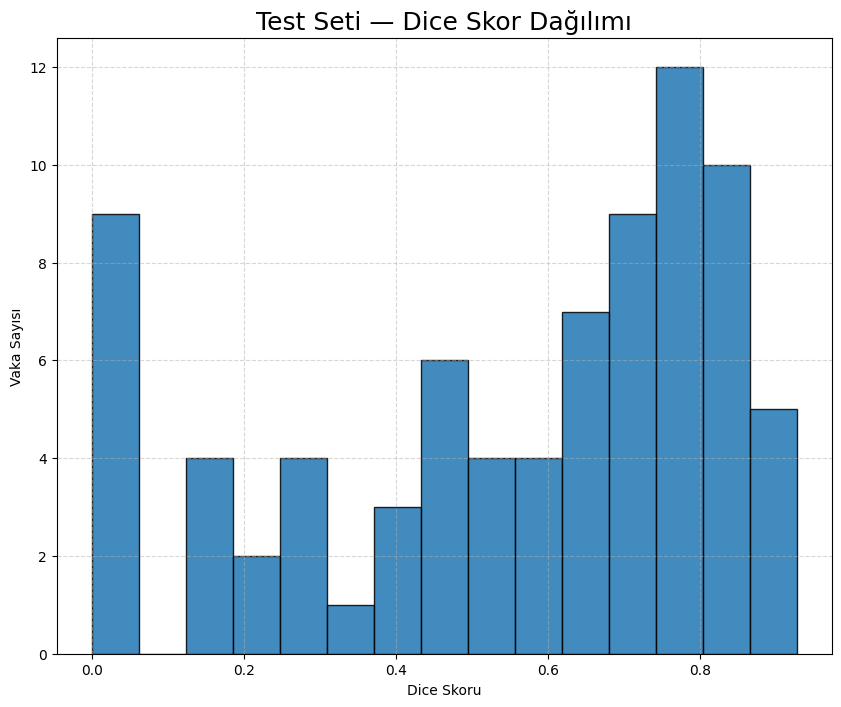

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.hist(valid_test["Dice"], bins=15, edgecolor="black", alpha=0.85)
plt.title("Test Seti — Dice Skor Dağılımı", fontsize=18)
plt.xlabel("Dice Skoru")
plt.ylabel("Vaka Sayısı")
plt.grid(True, linestyle="--", alpha=0.5)

plt.savefig(
    os.path.join(test_outdir, "test_dice_histogram.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


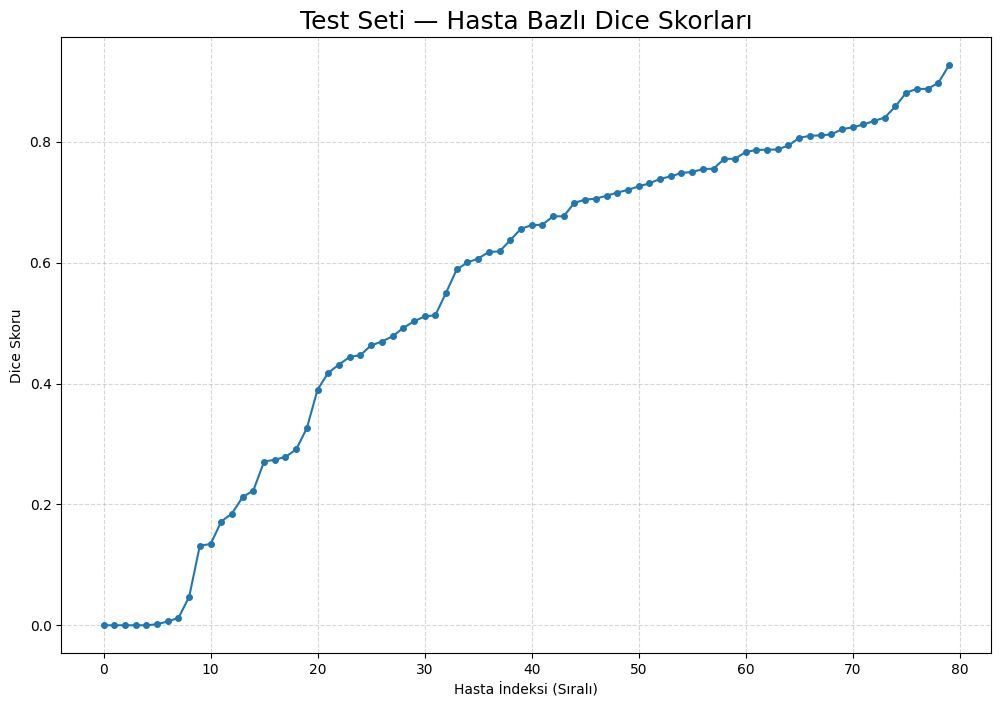

In [ ]:
plt.figure(figsize=(12, 8))

sorted_test = valid_test.sort_values("Dice").reset_index(drop=True)
plt.plot(
    sorted_test.index,
    sorted_test["Dice"],
    marker="o",
    markersize=4
)

plt.title("Test Seti — Hasta Bazlı Dice Skorları", fontsize=18)
plt.xlabel("Hasta İndeksi (Sıralı)")
plt.ylabel("Dice Skoru")
plt.grid(True, linestyle="--", alpha=0.5)

plt.savefig(
    os.path.join(test_outdir, "test_dice_per_patient.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


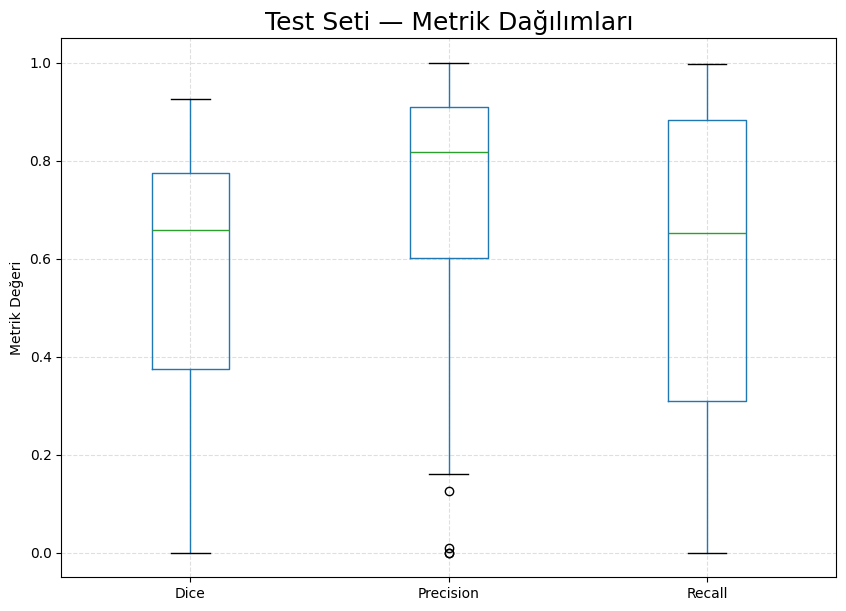

In [ ]:
plt.figure(figsize=(10, 7))

valid_test[["Dice", "Precision", "Recall"]].boxplot()
plt.title("Test Seti — Metrik Dağılımları", fontsize=18)
plt.ylabel("Metrik Değeri")
plt.grid(True, linestyle="--", alpha=0.4)

plt.savefig(
    os.path.join(test_outdir, "test_boxplot_metrics.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


Kaydetme

In [ ]:
import os

test_outdir = os.path.join(exp_dir, "test_figs")
os.makedirs(test_outdir, exist_ok=True)

print("📂 Test figür & CSV klasörü:", test_outdir)


📂 Test figür & CSV klasörü: /content/drive/MyDrive/UNet_experiments/UNetpp_3D_NIFTI_run_fixed/test_figs


In [ ]:
import pandas as pd

test_metrics_csv = os.path.join(test_outdir, "test_metrics_per_case.csv")

df_test_cases[["Dice", "Precision", "Recall"]].to_csv(
    test_metrics_csv,
    index=False
)

print("✅ Case-based test metrikleri kaydedildi:")
print(test_metrics_csv)


✅ Case-based test metrikleri kaydedildi:
/content/drive/MyDrive/UNet_experiments/UNetpp_3D_NIFTI_run_fixed/test_figs/test_metrics_per_case.csv


In [ ]:
hist_csv = os.path.join(test_outdir, "test_dice_values.csv")

df_test_cases[["Dice"]].dropna().to_csv(hist_csv, index=False)


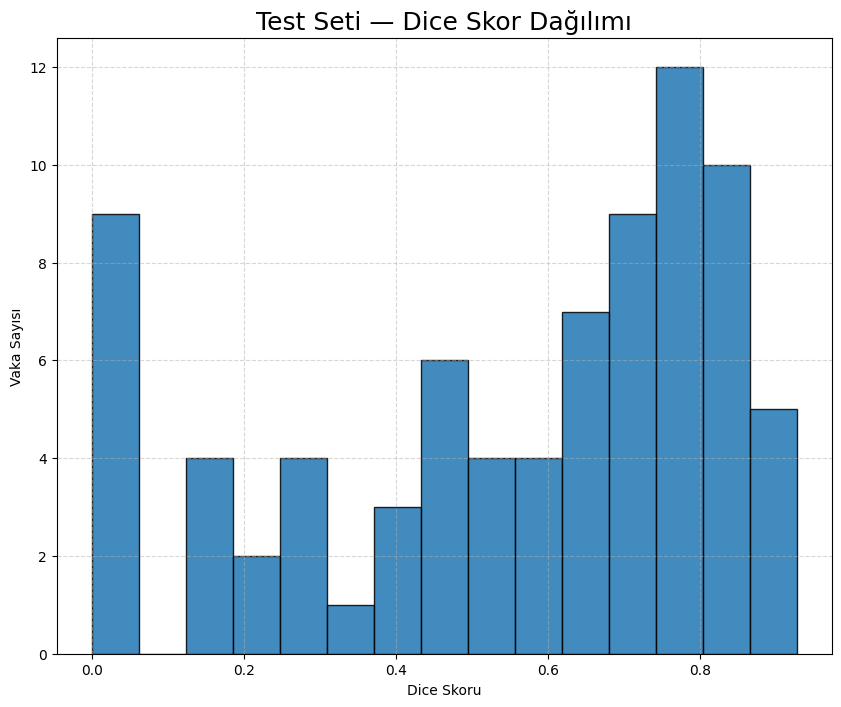

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.hist(df_test_cases["Dice"].dropna(), bins=15, edgecolor="black", alpha=0.85)
plt.title("Test Seti — Dice Skor Dağılımı", fontsize=18)
plt.xlabel("Dice Skoru")
plt.ylabel("Vaka Sayısı")
plt.grid(True, linestyle="--", alpha=0.5)

plt.savefig(
    os.path.join(test_outdir, "test_dice_histogram.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [ ]:
sorted_dice_csv = os.path.join(test_outdir, "test_dice_sorted.csv")

sorted_test = (
    df_test_cases[["Dice"]]
    .dropna()
    .sort_values("Dice")
    .reset_index(drop=True)
)

sorted_test.to_csv(sorted_dice_csv, index=False)


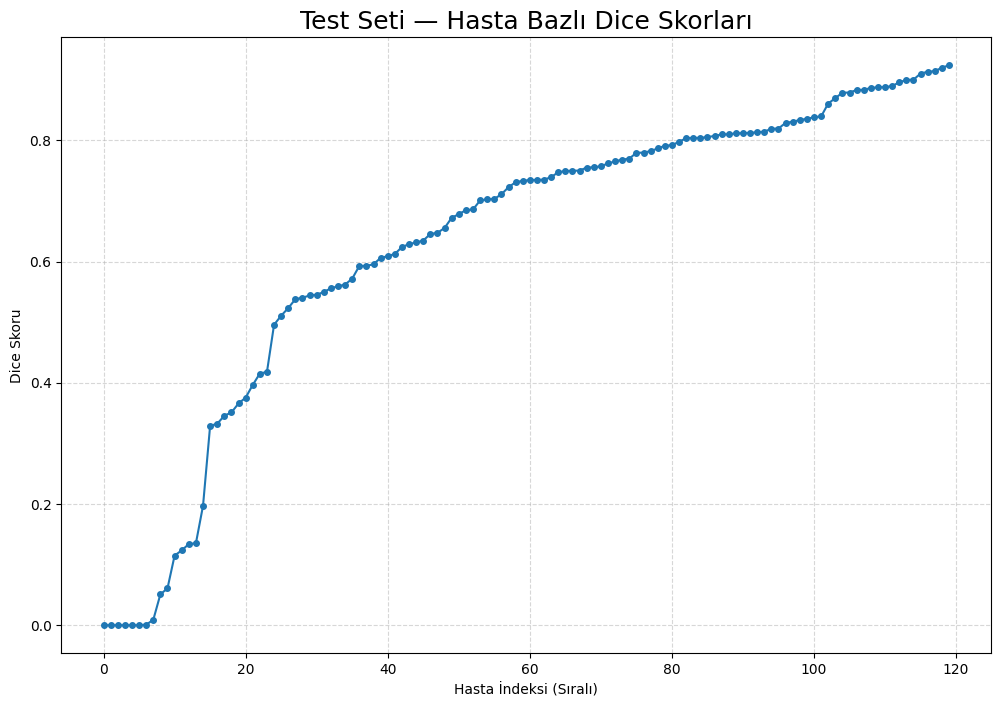

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(
    sorted_test.index,
    sorted_test["Dice"],
    marker="o",
    markersize=4
)

plt.title("Test Seti — Hasta Bazlı Dice Skorları", fontsize=18)
plt.xlabel("Hasta İndeksi (Sıralı)")
plt.ylabel("Dice Skoru")
plt.grid(True, linestyle="--", alpha=0.5)

plt.savefig(
    os.path.join(test_outdir, "test_dice_per_patient.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [ ]:
boxplot_csv = os.path.join(test_outdir, "test_boxplot_metrics.csv")

df_test_cases[["Dice", "Precision", "Recall"]].dropna().to_csv(
    boxplot_csv,
    index=False
)


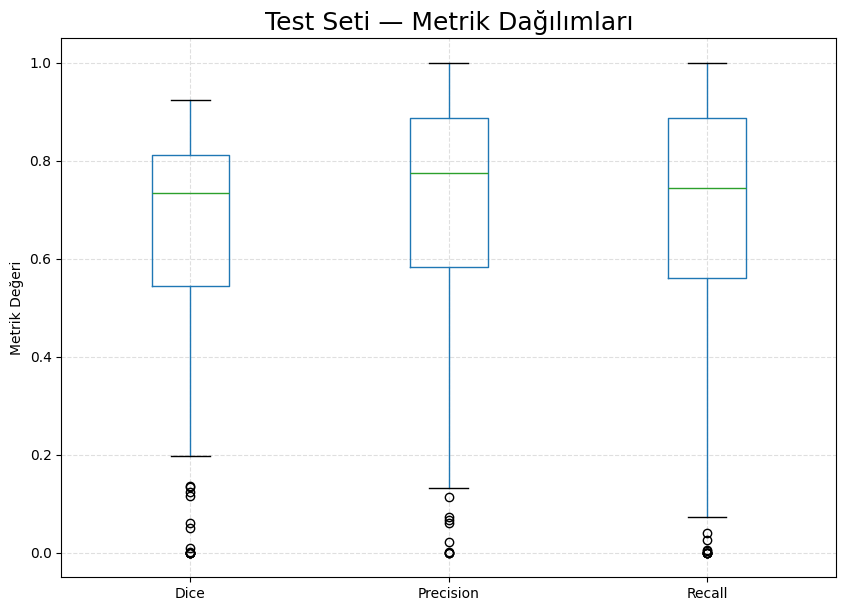

In [ ]:
plt.figure(figsize=(10, 7))

df_test_cases[["Dice", "Precision", "Recall"]].dropna().boxplot()
plt.title("Test Seti — Metrik Dağılımları", fontsize=18)
plt.ylabel("Metrik Değeri")
plt.grid(True, linestyle="--", alpha=0.4)

plt.savefig(
    os.path.join(test_outdir, "test_boxplot_metrics.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/dataset"


In [ ]:
# ÖRNEK PID (istediğini yazabilirsin)
pid = "ispy2_453596"

In [ ]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# Test klasörleri
test_img_dir = os.path.join(BASE_DIR, "test", "images")
test_msk_dir = os.path.join(BASE_DIR, "test", "masks")

img_path = os.path.join(test_img_dir, f"{pid}_0000.nii.gz")
msk_path = os.path.join(test_msk_dir, f"{pid}.nii.gz")

print("Image path:", img_path)
print("Mask  path:", msk_path)


Image path: /content/drive/MyDrive/dataset/test/images/ispy2_453596_0000.nii.gz
Mask  path: /content/drive/MyDrive/dataset/test/masks/ispy2_453596.nii.gz


In [ ]:
# NIFTI yükle
img = nib.load(img_path).get_fdata().astype(np.float32)
msk = nib.load(msk_path).get_fdata().astype(np.uint8)

print("✨ Image shape:", img.shape)
print("✨ Mask  shape:", msk.shape)


✨ Image shape: (160, 160, 80)
✨ Mask  shape: (160, 160, 80)


In [ ]:
# Model input formatına sok
img_in = img[np.newaxis, ..., np.newaxis]  # (1, X, Y, Z, 1)

# Logits
logits = best_model.predict(img_in, verbose=0)[0]

# Sigmoid + threshold
probs = 1.0 / (1.0 + np.exp(-logits))
pred_bin = (probs > 0.5).astype(np.uint8)

print("✨ Prediction shape:", pred_bin.shape)


✨ Prediction shape: (160, 160, 80, 1)


/tmp/ipython-input-1382344024.py:8: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))


In [ ]:
slice_index = 40
# ya da manuel:
# slice_index = 25


(np.float64(-0.5), np.float64(159.5), np.float64(159.5), np.float64(-0.5))

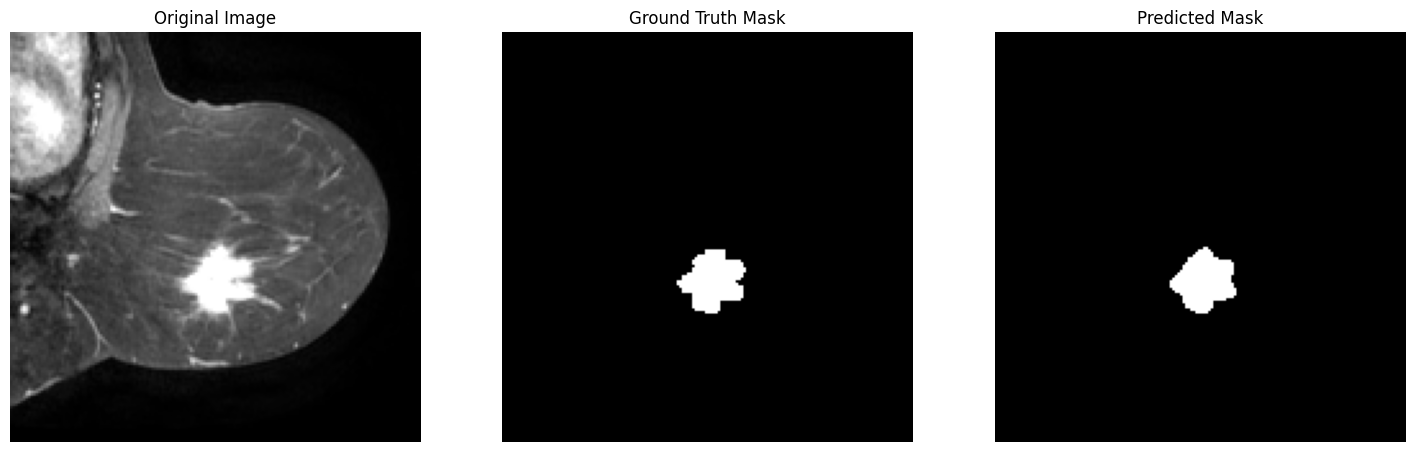

In [ ]:
plt.figure(figsize=(18, 6))

# ----------------
# 1) Orijinal Görüntü
# ----------------
plt.subplot(1, 3, 1)
plt.imshow(img[:, :, slice_index], cmap="gray")
plt.title("Original Image")
plt.axis("off")

# ----------------
# 2) Ground Truth
# ----------------
plt.subplot(1, 3, 2)
plt.imshow(msk[:, :, slice_index], cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

# ----------------
# 3) Prediction
# ----------------
plt.subplot(1, 3, 3)
plt.imshow(pred_bin[:, :, slice_index], cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

# plt.suptitle(f"Test Case: {pid}", fontsize=16)
# plt.tight_layout()
# plt.show()



In [ ]:
# ÖRNEK: "ispy2_132463" gibi bir PID yaz
pid = "ispy2_132463"   # ← burada istediğini değiştirebilirsin

# Test görüntüsü + maskeyi + prediction’ı yükle
import numpy as np
import matplotlib.pyplot as plt
import os

# Dosya yolları
img_path = os.path.join(test_img, f"{pid}_0000.npy")
msk_path = os.path.join(test_msk, f"{pid}.npy")

# Yükleme
img = np.load(img_path)
msk = np.load(msk_path)

# Prediction üretme
pred = best_model.predict(img[np.newaxis, ...])[0]
pred_bin = (pred > 0.5).astype(np.float32)

print("✨ Orijinal görüntü boyutu:", img.shape)


In [ ]:
slice_index = 25  # ← burayı istediğin gibi değiştir

plt.figure(figsize=(18, 6))

# ----------------
# 1) Orijinal Görüntü
# ----------------
plt.subplot(1, 3, 1)
plt.imshow(img[:, :, slice_index, 0], cmap="gray")
plt.title("Original Image")
plt.axis("off")

# ----------------
# 2) Ground Truth Mask
# ----------------
plt.subplot(1, 3, 2)
plt.imshow(msk[:, :, slice_index, 0], cmap="gray")
plt.title("Groundtruth Mask")
plt.axis("off")

# ----------------
# 3) Prediction
# ----------------
plt.subplot(1, 3, 3)
plt.imshow(pred_bin[:, :, slice_index, 0], cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
print("Image shape:", img.shape)
print("Mask shape:", msk.shape)
print("Prediction shape:", pred_bin.shape)


Image shape: (160, 160, 80, 1)
Mask shape: (160, 160, 80, 1)
Prediction shape: (160, 160, 80, 1)


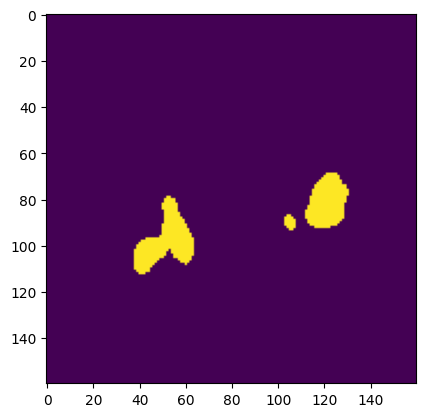

In [ ]:
plt.imshow(msk[:,:,::-1,0][:,:,slice_index])
plt.imshow(pred_bin[:,:,slice_index,0])


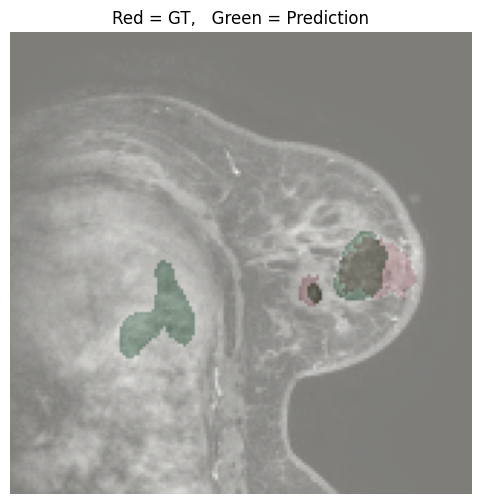

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(img[:,:,slice_index,0], cmap="gray")
plt.imshow(msk[:,:,slice_index,0], alpha=0.3, cmap="Reds")    # GT kırmızı
plt.imshow(pred_bin[:,:,slice_index,0], alpha=0.3, cmap="Greens")  # Prediction yeşil
plt.title("Red = GT,   Green = Prediction")
plt.axis("off")
plt.show()


In [ ]:
np.flip()
array[::-1]
transposition
crop
resize


TypeError: flip() missing 1 required positional argument: 'm'

In [ ]:
# ÖRNEK: "ispy2_132463" gibi bir PID yaz
pid = "ispy1_1053"   # ← burada istediğini değiştirebilirsin

# Test görüntüsü + maskeyi + prediction’ı yükle
import numpy as np
import matplotlib.pyplot as plt
import os

# Dosya yolları
img_path = os.path.join(test_img, f"{pid}_0000.npy")
msk_path = os.path.join(test_msk, f"{pid}.npy")

# Yükleme
img = np.load(img_path)
msk = np.load(msk_path)

# Prediction üretme
pred = best_model.predict(img[np.newaxis, ...])[0]
pred_bin = (pred > 0.5).astype(np.float32)

print("✨ Orijinal görüntü boyutu:", img.shape)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
✨ Orijinal görüntü boyutu: (160, 160, 80, 1)


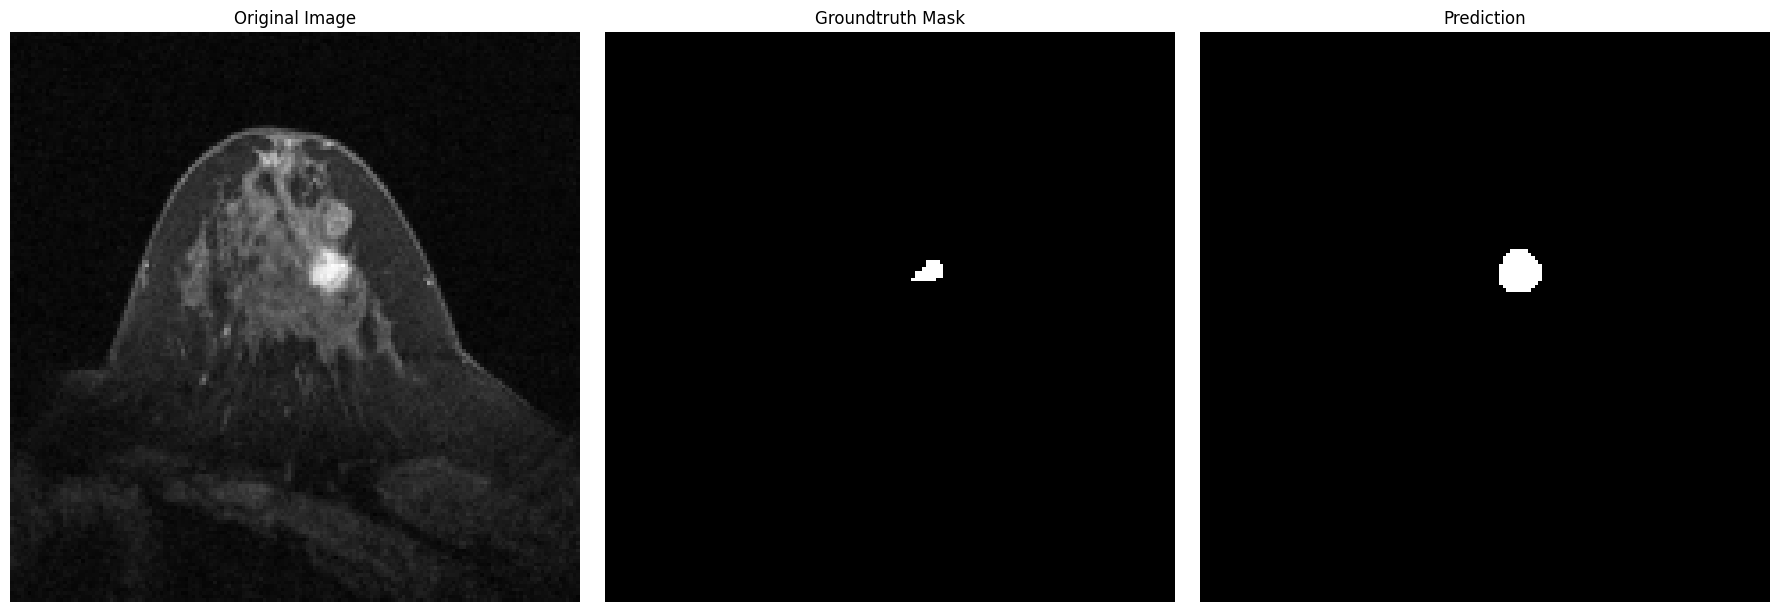

In [ ]:
slice_index = 55  # ← burayı istediğin gibi değiştir

plt.figure(figsize=(18, 6))

# ----------------
# 1) Orijinal Görüntü
# ----------------
plt.subplot(1, 3, 1)
plt.imshow(img[:, :, slice_index, 0], cmap="gray")
plt.title("Original Image")
plt.axis("off")

# ----------------
# 2) Ground Truth Mask
# ----------------
plt.subplot(1, 3, 2)
plt.imshow(msk[:, :, slice_index, 0], cmap="gray")
plt.title("Groundtruth Mask")
plt.axis("off")

# ----------------
# 3) Prediction
# ----------------
plt.subplot(1, 3, 3)
plt.imshow(pred_bin[:, :, slice_index, 0], cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()


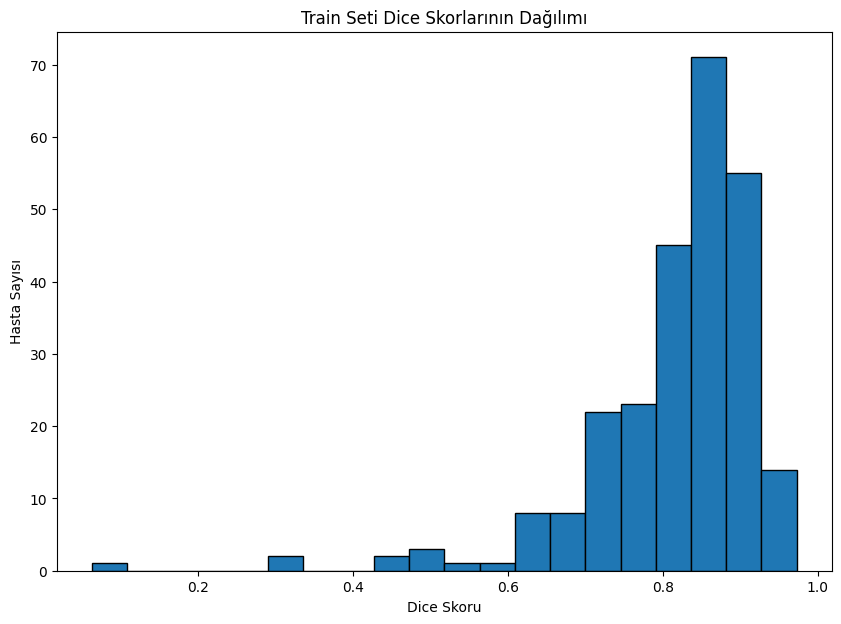

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.hist(train_dice, bins=20, edgecolor='black')
plt.title("Train Seti Dice Skorlarının Dağılımı")
plt.xlabel("Dice Skoru")
plt.ylabel("Hasta Sayısı")
plt.grid(False)
plt.show()


In [ ]:
def precision_np(y_true, y_pred, smooth=1e-7):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    tp = np.sum((y_true_f==1) & (y_pred_f==1))
    fp = np.sum((y_true_f==0) & (y_pred_f==1))
    return (tp + smooth) / (tp + fp + smooth)

def recall_np(y_true, y_pred, smooth=1e-7):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    tp = np.sum((y_true_f==1) & (y_pred_f==1))
    fn = np.sum((y_true_f==1) & (y_pred_f==0))
    return (tp + smooth) / (tp + fn + smooth)

train_precision = []
train_recall = []

for i in range(len(all_train_preds)):
    train_precision.append(precision_np(all_train_trues[i], all_train_preds[i]))
    train_recall.append(recall_np(all_train_trues[i], all_train_preds[i]))


/tmp/ipython-input-359807748.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([train_dice, train_precision, train_recall], labels=["Dice", "Precision", "Recall"])


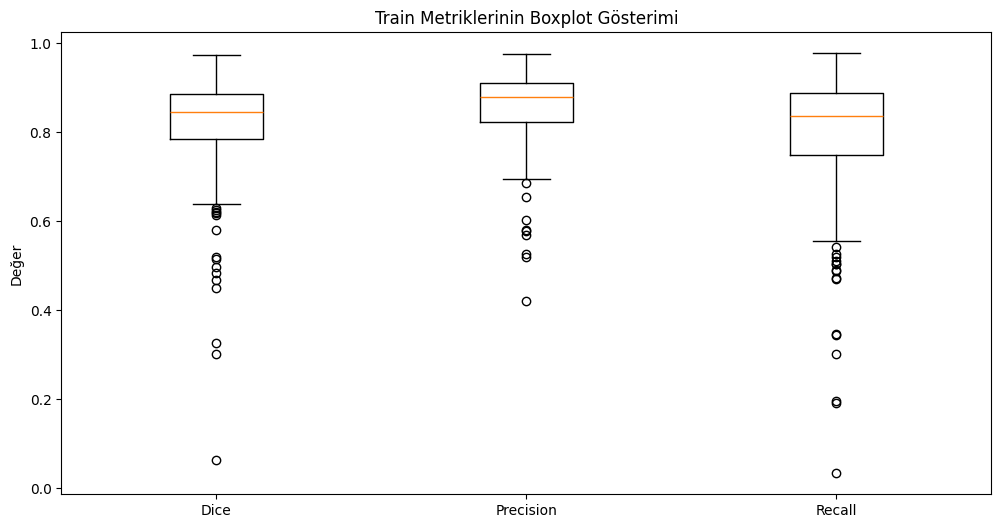

In [ ]:
plt.figure(figsize=(12,6))
plt.boxplot([train_dice, train_precision, train_recall], labels=["Dice", "Precision", "Recall"])
plt.title("Train Metriklerinin Boxplot Gösterimi")
plt.ylabel("Değer")
plt.grid(False)
plt.show()


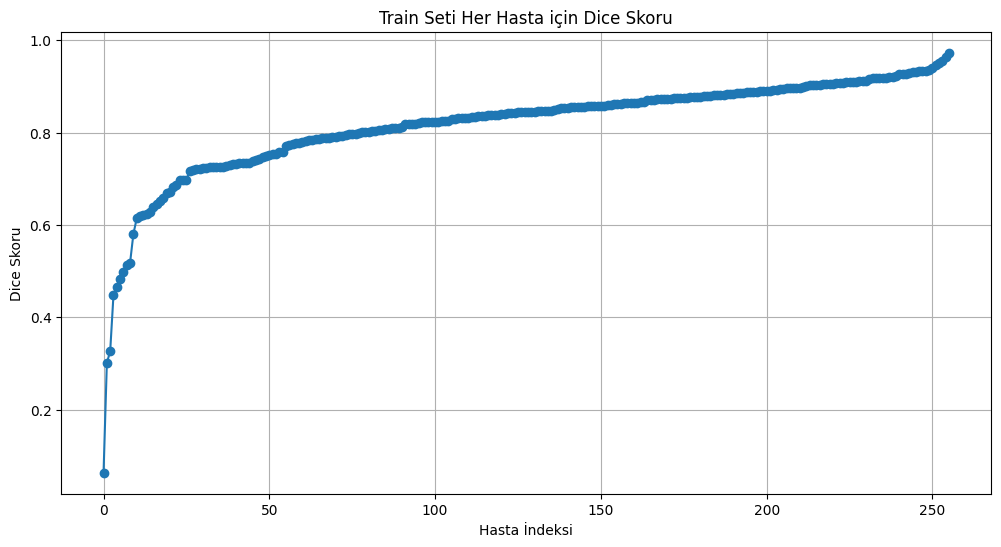

In [ ]:
sorted_dice = sorted(train_dice)

plt.figure(figsize=(12,6))
plt.plot(sorted_dice, marker='o')
plt.title("Train Seti Her Hasta için Dice Skoru")
plt.xlabel("Hasta İndeksi")
plt.ylabel("Dice Skoru")
plt.grid(True)
plt.show()


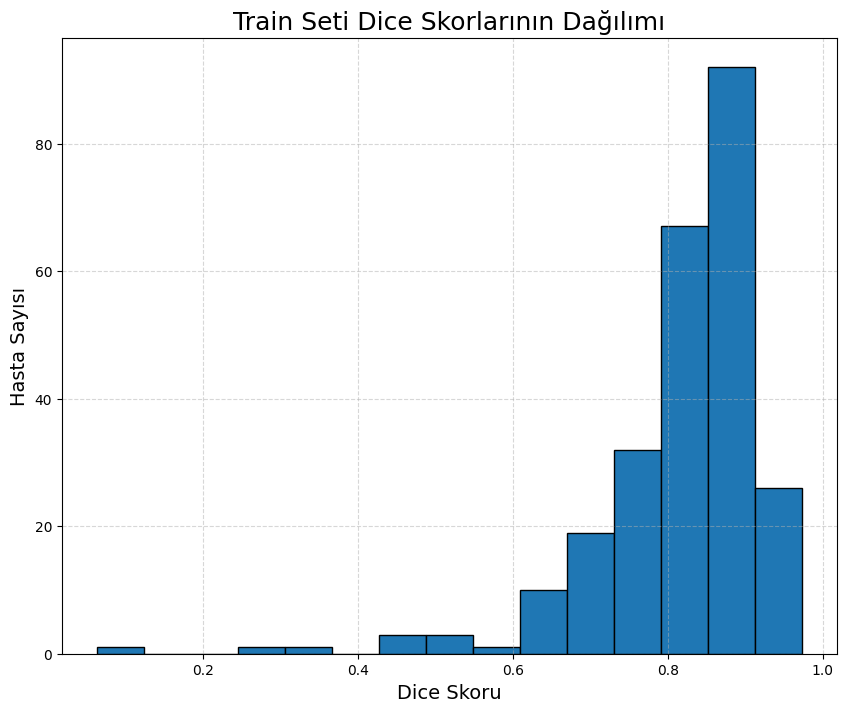

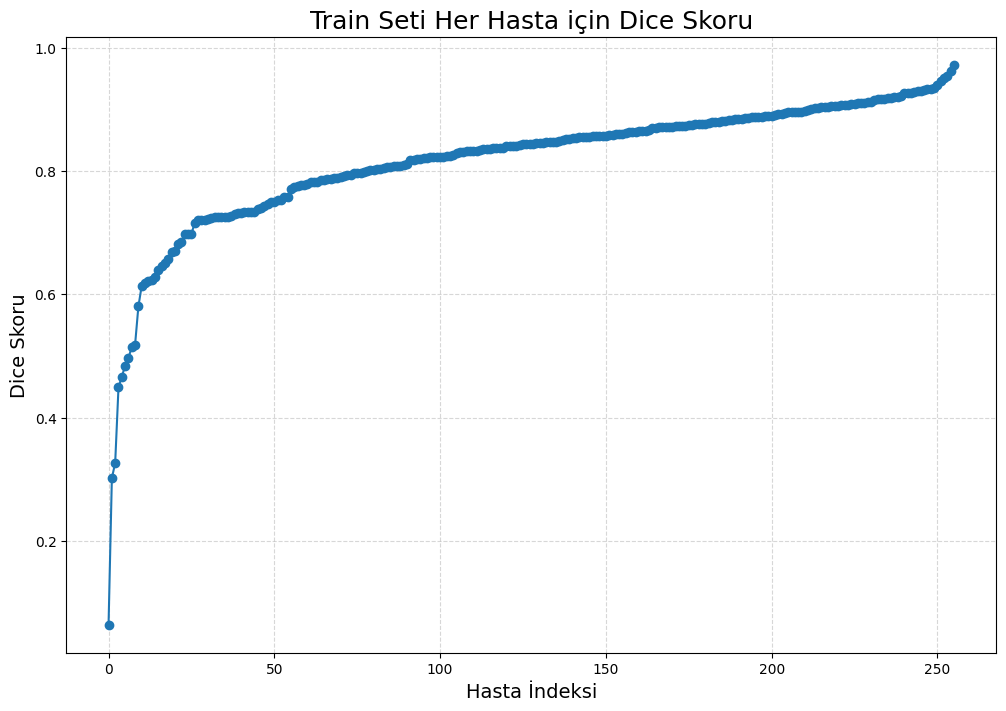

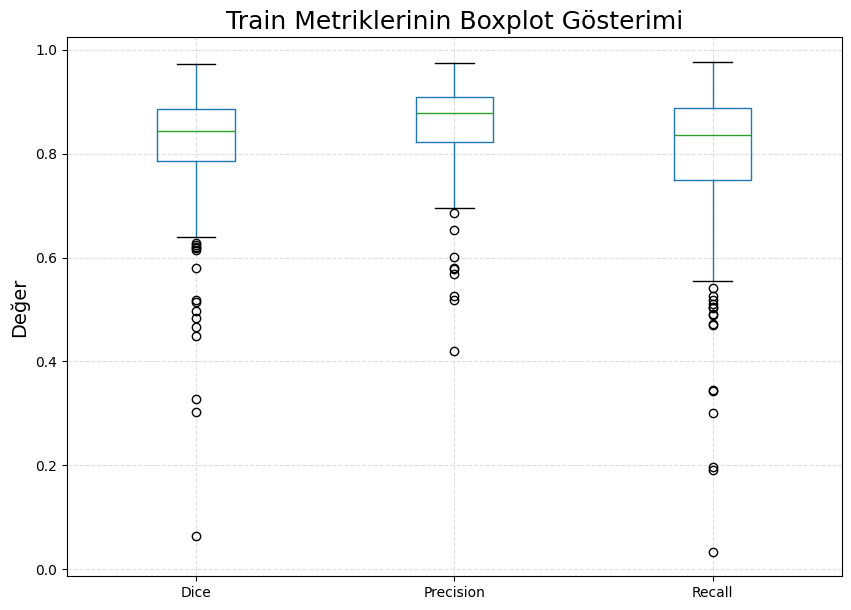

🖼️ Train grafikler kaydedildi: /content/drive/MyDrive/UNetPP_results/train_figs


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# ================================
# 1) Sonuçları DataFrame'e dönüştür
# ================================
train_df = pd.DataFrame({
    "Dice": train_dice,
    "Precision": train_precision,
    "Recall": train_recall
})

# Eğer NaN varsa at
valid_train = train_df.dropna()

# ================================
# 2) Klasör oluştur
# ================================
outdir = "/content/drive/MyDrive/UNetPP_results/train_figs"
os.makedirs(outdir, exist_ok=True)

# ================================
# 1) HISTOGRAM (Dice)
# ================================
plt.figure(figsize=(10, 8))
plt.hist(valid_train["Dice"], bins=15, edgecolor="black")
plt.title("Train Seti Dice Skorlarının Dağılımı", fontsize=18)
plt.xlabel("Dice Skoru", fontsize=14)
plt.ylabel("Hasta Sayısı", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig(os.path.join(outdir, "train_dice_histogram.png"))
plt.show()

# ================================
# 2) LINE PLOT (Her Hasta için Dice)
# ================================
plt.figure(figsize=(12, 8))
sorted_train = valid_train.sort_values("Dice").reset_index(drop=True)
plt.plot(sorted_train.index, sorted_train["Dice"], marker="o")
plt.title("Train Seti Her Hasta için Dice Skoru", fontsize=18)
plt.xlabel("Hasta İndeksi", fontsize=14)
plt.ylabel("Dice Skoru", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig(os.path.join(outdir, "train_dice_per_patient.png"))
plt.show()

# ================================
# 3) BOX PLOT (Dice, Precision, Recall)
# ================================
plt.figure(figsize=(10, 7))
valid_train[["Dice", "Precision", "Recall"]].boxplot()
plt.title("Train Metriklerinin Boxplot Gösterimi", fontsize=18)
plt.ylabel("Değer", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.4)
plt.savefig(os.path.join(outdir, "train_boxplot_metrics.png"))
plt.show()

print("🖼️ Train grafikler kaydedildi:", outdir)


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/unetpp_best.h5", compile=False)
print("✔ Model loaded.")



In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

case = "ispy1_1082"  # hasta id

img_path = f"/content/drive/MyDrive/dataset/test/images/{case}_0000.npy"
gt_path  = f"/content/drive/MyDrive/dataset/test/masks/{case}.npy"


In [ ]:
img = np.load(img_path)
gt  = np.load(gt_path)

print("Image shape:", img.shape)
print("Mask shape:", gt.shape)


Image shape: (160, 160, 80, 1)
Mask shape: (160, 160, 80, 1)


In [ ]:
img_input = img.astype(np.float32)[None, ..., None]  # (1,160,160,80,1)

pred = model.predict(img_input)[0, ..., 0]
pred_bin = (pred > 0.5).astype(np.uint8)

print("Prediction shape:", pred_bin.shape)


NameError: name 'model' is not defined

In [ ]:
slice_idx = 50


NameError: name 'pred_bin' is not defined

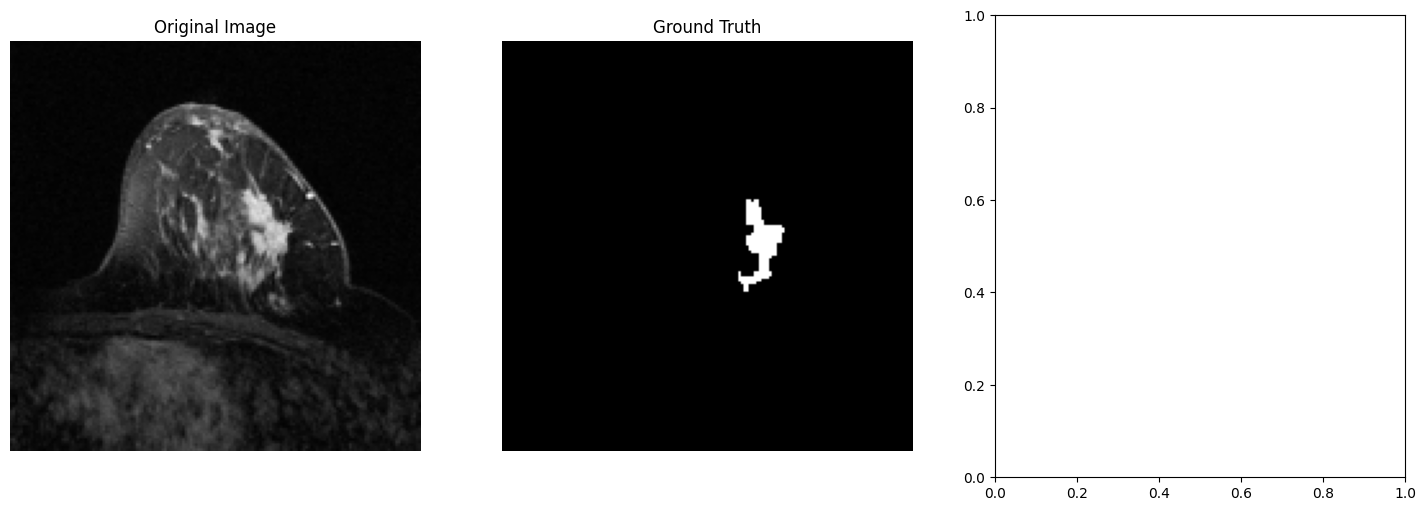

In [ ]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img[:, :, slice_idx], cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt[:, :, slice_idx], cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_bin[:, :, slice_idx], cmap="gray")
plt.title("Prediction")
plt.axis("off")

output_path = "/content/unetpp_slice.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.close()

print("Saved at:", output_path)
display(Image(output_path))
